# 03 Modeling

This notebook trains and compares machine learning models for ATP and WTA match-winner prediction using the processed match-level dataset.

# Setup

Run this cell first so notebooks can import helpers from the `src/` folder.

In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

In [ ]:
from src.modeling import cross_validate_model, evaluate_classifier, append_result, results_table

In [ ]:
import pandas as pd

processed_path = PROJECT_ROOT / "data" / "processed" / "analysis_df.csv"
if not processed_path.exists():
    raise FileNotFoundError(
        f"{processed_path} not found. Run notebooks/01_data_cleaning.ipynb first."
    )
analysis_df = pd.read_csv(processed_path)
analysis_df.head()

In [ ]:
df = analysis_df.copy()

In [ ]:
df_atp = df[df['tour'] == 'atp']
df_wta = df[df['tour'] == 'wta']

In [ ]:
# Best feature set for ML: Final optimized version based on Correlation Ranking
# We exclude points_win_pct_diff because it is too closely related to the outcome (leakage)
ml_features = [
    #rally
    'winner_rate_diff',
    'ue_rate_diff',
    'break_win_pct_diff',
    'net_win_pct_diff',
    #serve
    'ace_rate_diff',
    'df_rate_diff',
    #return
    'returndepth_nd_diff'
]


# Target variable
target = 'match_winner'

X = df[ml_features]
y = df[target]

print(f'Final feature matrix X created with {X.shape[1]} features based on correlation ranking.')
print(f'Target vector y created (1 = Player 1 wins, 0 = Player 2 wins).')
display(X.head())

Final feature matrix X created with 7 features based on correlation ranking.
Target vector y created (1 = Player 1 wins, 0 = Player 2 wins).


,winner_rate_diff,ue_rate_diff,break_win_pct_diff,net_win_pct_diff,ace_rate_diff,df_rate_diff,returndepth_nd_diff
0,0.000000,0.018293,0.363636,0.169565,0.001208,-0.012195,1.0
1,-0.017094,0.029915,-0.114286,-0.111111,0.112281,-0.008547,2.0
2,0.017167,-0.051502,-0.095238,-0.017094,0.010456,0.004292,0.0
3,-0.059880,-0.029940,0.571429,-0.065657,-0.025251,0.023952,0.0
4,0.025926,0.014815,0.214286,-0.118841,0.086611,0.003704,0.0


In [ ]:
#train/test split
from sklearn.model_selection import train_test_split

X = df[ml_features]
y = df['match_winner']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_atp = df_atp[ml_features]
y_atp = df_atp['match_winner']

X_train_atp, X_test_atp, y_train_atp, y_test_atp = train_test_split(
    X_atp, y_atp, test_size=0.2, random_state=42
)

X_wta = df_wta[ml_features]
y_wta = df_wta['match_winner']

X_train_wta, X_test_wta, y_train_wta, y_test_wta = train_test_split(
    X_wta, y_wta, test_size=0.2, random_state=42
)


In [ ]:
atp_results = []
wta_results = []

In [ ]:
#Logistic Regression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
scoring = ['accuracy', 'f1']
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

log_pipe_atp = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

log_pipe_wta = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

In [ ]:
cv_results_atp = cross_validate(log_pipe_atp, X_train_atp, y_train_atp, cv=cv, scoring=scoring)

log_cv_f1_atp = cv_results_atp['test_f1'].mean()
log_cv_accuracy_atp = cv_results_atp['test_accuracy'].mean()


In [ ]:
cv_results_wta = cross_validate(log_pipe_wta, X_train_wta, y_train_wta, cv=cv, scoring=scoring)

log_cv_f1_wta = cv_results_wta['test_f1'].mean()
log_cv_accuracy_wta = cv_results_wta['test_accuracy'].mean()

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
log_pipe_atp.fit(X_train_atp, y_train_atp)
y_pred_atp = log_pipe_atp.predict(X_test_atp)

print("ATP Test Accuracy:", accuracy_score(y_test_atp, y_pred_atp))
print("ATP Test f1 score:", f1_score(y_test_atp, y_pred_atp))
print(confusion_matrix(y_test_atp, y_pred_atp))

ATP Test Accuracy: 0.8543046357615894
ATP Test f1 score: 0.8405797101449275
[[71  9]
 [13 58]]


In [ ]:
log_pipe_wta.fit(X_train_wta, y_train_wta)
y_pred_wta = log_pipe_wta.predict(X_test_wta)

print("WTA Test Accuracy:", accuracy_score(y_test_wta, y_pred_wta))
print("WTA Test f1 score:", f1_score(y_test_wta, y_pred_wta))
print(confusion_matrix(y_test_wta, y_pred_wta))

WTA Test Accuracy: 0.9133333333333333
WTA Test f1 score: 0.9090909090909091
[[72  7]
 [ 6 65]]


In [ ]:
atp_results.append({
    'model': 'Logistic Regression',
    'cv_accuracy':log_cv_accuracy_atp,
    'cv_f1': log_cv_f1_atp,
    'test_accuracy': accuracy_score(y_test_atp, y_pred_atp),
    'test_f1': f1_score(y_test_atp, y_pred_atp),
})

wta_results.append({
    'model': 'Logistic Regression',
    'cv_accuracy': log_cv_accuracy_wta,
    'cv_f1': log_cv_f1_wta,
    'test_accuracy': accuracy_score(y_test_wta, y_pred_wta),
    'test_f1': f1_score(y_test_wta, y_pred_wta),
})

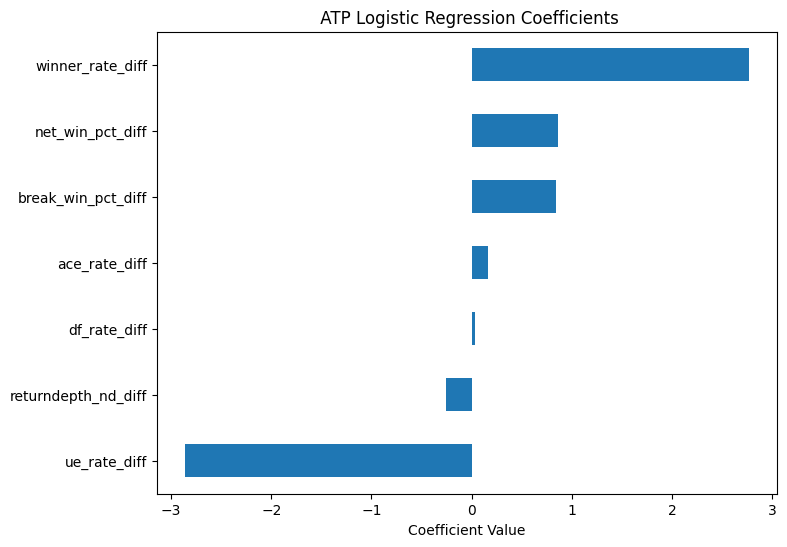

In [ ]:
#coefficient plot
coefficients = pd.Series(log_pipe_atp.named_steps['model'].coef_[0], index=ml_features)
coefficients = coefficients.sort_values()

plt.figure(figsize=(8,6))
coefficients.plot(kind='barh')
plt.title(" ATP Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.show()

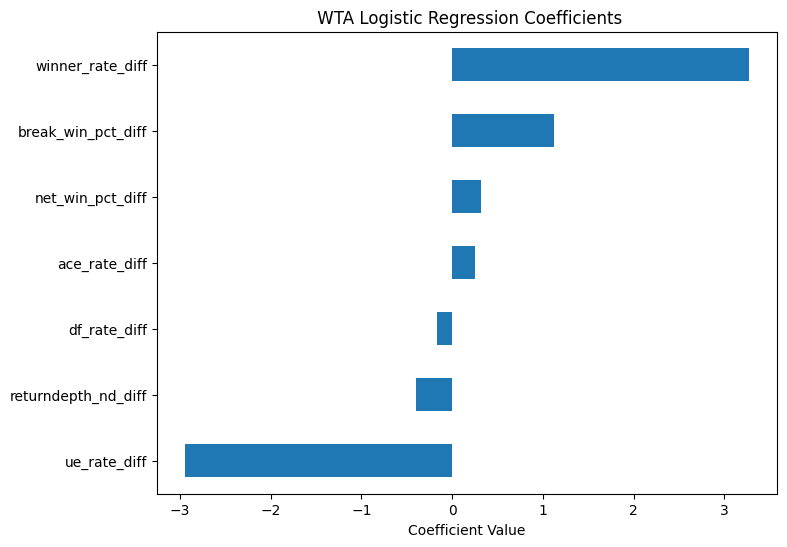

In [ ]:
coefficients = pd.Series(log_pipe_wta.named_steps['model'].coef_[0], index=ml_features)
coefficients = coefficients.sort_values()

plt.figure(figsize=(8,6))
coefficients.plot(kind='barh')
plt.title(" WTA Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.show()

In [ ]:
coef_atp = log_pipe_atp.named_steps['model'].coef_[0]
coef_wta = log_pipe_wta.named_steps['model'].coef_[0]

coef_df_atp = pd.DataFrame({
    'feature': ml_features,
    'coefficient': coef_atp
}).sort_values('coefficient', ascending=False)

coef_df_wta = pd.DataFrame({
    'feature': ml_features,
    'coefficient': coef_wta
}).sort_values('coefficient', ascending=False)

print(coef_df_atp)
print(coef_df_wta)

               feature  coefficient
0     winner_rate_diff     2.767681
3     net_win_pct_diff     0.862779
2   break_win_pct_diff     0.839912
4        ace_rate_diff     0.167527
5         df_rate_diff     0.030092
6  returndepth_nd_diff    -0.251589
1         ue_rate_diff    -2.857930
               feature  coefficient
0     winner_rate_diff     3.272069
2   break_win_pct_diff     1.128432
3     net_win_pct_diff     0.315778
4        ace_rate_diff     0.252872
5         df_rate_diff    -0.170542
6  returndepth_nd_diff    -0.396245
1         ue_rate_diff    -2.942030


In [ ]:
#random forest
from sklearn.ensemble import RandomForestClassifier

rf_atp = RandomForestClassifier(n_estimators=200, random_state=42)
rf_wta = RandomForestClassifier(n_estimators=200, random_state=42)

cv_results_rf_atp = cross_validate(
    rf_atp,
    X_train_atp,
    y_train_atp,
    cv=cv,
    scoring=scoring
)
rf_cv_f1_atp = cv_results_rf_atp['test_f1'].mean()
rf_cv_accuracy_atp = cv_results_rf_atp['test_accuracy'].mean()


cv_results_rf_wta = cross_validate(
    rf_wta,
    X_train_wta,
    y_train_wta,
    cv=cv,
    scoring=scoring
)
rf_cv_f1_wta = cv_results_rf_wta['test_f1'].mean()
rf_cv_accuracy_wta = cv_results_rf_wta['test_accuracy'].mean()

In [ ]:
from sklearn.metrics import f1_score
rf_atp.fit(X_train_atp, y_train_atp)

y_pred_atp = rf_atp.predict(X_test_atp)

print("ATP RF Test Accuracy:", accuracy_score(y_test_atp, y_pred_atp))
print("ATP RF Test F1 score:", f1_score(y_test_atp, y_pred_atp))
print(confusion_matrix(y_test_atp, y_pred_atp))

ATP RF Test Accuracy: 0.8609271523178808
ATP RF Test F1 score: 0.8467153284671532
[[72  8]
 [13 58]]


In [ ]:
rf_wta.fit(X_train_wta, y_train_wta)

y_pred_wta = rf_wta.predict(X_test_wta)

print("WTA RF Test Accuracy:", accuracy_score(y_test_wta, y_pred_wta))
print("WTA RF Test f1 score:", f1_score(y_test_wta, y_pred_wta))
print(confusion_matrix(y_test_wta, y_pred_wta))

WTA RF Test Accuracy: 0.8933333333333333
WTA RF Test f1 score: 0.8873239436619719
[[71  8]
 [ 8 63]]


In [ ]:
atp_results.append({
    'model': 'Random Forest',
    'cv_accuracy':rf_cv_accuracy_atp,
    'cv_f1': rf_cv_f1_atp,
    'test_accuracy': accuracy_score(y_test_atp, y_pred_atp),
    'test_f1': f1_score(y_test_atp, y_pred_atp),
})

wta_results.append({
    'model': 'Random Forest',
    'cv_accuracy': rf_cv_accuracy_wta,
    'cv_f1': rf_cv_f1_wta,
    'test_accuracy': accuracy_score(y_test_wta, y_pred_wta),
    'test_f1': f1_score(y_test_wta, y_pred_wta),
})

In [ ]:
from sklearn.model_selection import GridSearchCV
rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 3, 5, 7],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': ['sqrt', 'log2', None]
}

In [ ]:
rf_search_atp = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    n_jobs=-1,
    scoring='f1'
)

In [ ]:
rf_search_atp.fit(X_train_atp, y_train_atp)

print("Best ATP params:", rf_search_atp.best_params_)
print("Best ATP CV score:", rf_search_atp.best_score_)


Best ATP params: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
Best ATP CV score: 0.8640383571510928


In [ ]:
b_rf_atp = rf_search_atp.best_estimator_
b_y_pred_atp = b_rf_atp.predict(X_test_atp)


print("ATP tuned RF Test f1 score:", f1_score(y_test_atp, b_y_pred_atp))
print("ATP tuned RF Test accuracy:", accuracy_score(y_test_atp, b_y_pred_atp))

print(classification_report(y_test_atp, b_y_pred_atp))
print(confusion_matrix(y_test_atp, b_y_pred_atp))

ATP tuned RF Test f1 score: 0.8571428571428571
ATP tuned RF Test accuracy: 0.8675496688741722
              precision    recall  f1-score   support

           0       0.87      0.89      0.88        80
           1       0.87      0.85      0.86        71

    accuracy                           0.87       151
   macro avg       0.87      0.87      0.87       151
weighted avg       0.87      0.87      0.87       151

[[71  9]
 [11 60]]


In [ ]:
rf_search_wta = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    n_jobs=-1,
    scoring='f1'
)

In [ ]:
rf_search_wta.fit(X_train_wta, y_train_wta)

print("Best WTA params:", rf_search_wta.best_params_)
print("Best WTA CV score:", rf_search_wta.best_score_)

Best WTA params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best WTA CV score: 0.8867432923582657


In [ ]:
b_rf_wta = rf_search_wta.best_estimator_
b_y_pred_wta = b_rf_wta.predict(X_test_wta)


print("WTA tuned RF Test f1 score:", f1_score(y_test_wta, b_y_pred_wta))
print("WTA tuned RF Test accuracy", accuracy_score(y_test_wta, b_y_pred_wta))

print(classification_report(y_test_wta, b_y_pred_wta))
print(confusion_matrix(y_test_wta, b_y_pred_wta))

WTA tuned RF Test f1 score: 0.8811188811188811
WTA tuned RF Test accuracy 0.8866666666666667
              precision    recall  f1-score   support

           0       0.90      0.89      0.89        79
           1       0.88      0.89      0.88        71

    accuracy                           0.89       150
   macro avg       0.89      0.89      0.89       150
weighted avg       0.89      0.89      0.89       150

[[70  9]
 [ 8 63]]


In [ ]:
atp_results.append({
    'model': 'tuned Random Forest',
    'cv_accuracy': None,
    'cv_f1': rf_search_atp.best_score_,
    'test_accuracy': accuracy_score(y_test_atp, b_y_pred_atp),
    'test_f1': f1_score(y_test_atp, b_y_pred_atp),
})

wta_results.append({
    'model': 'tuned Random Forest',
    'cv_accuracy': None,
    'cv_f1': rf_search_wta.best_score_,
    'test_accuracy': accuracy_score(y_test_wta, b_y_pred_wta),
    'test_f1': f1_score(y_test_wta, b_y_pred_wta),
})

In [ ]:
b_rf_atp_importance = pd.Series(b_rf_atp.feature_importances_, index=ml_features)
importance = b_rf_atp_importance.sort_values(ascending=False)

print(importance)

winner_rate_diff       0.235217
ue_rate_diff           0.227498
net_win_pct_diff       0.180661
break_win_pct_diff     0.154385
ace_rate_diff          0.103928
returndepth_nd_diff    0.066021
df_rate_diff           0.032291
dtype: float64


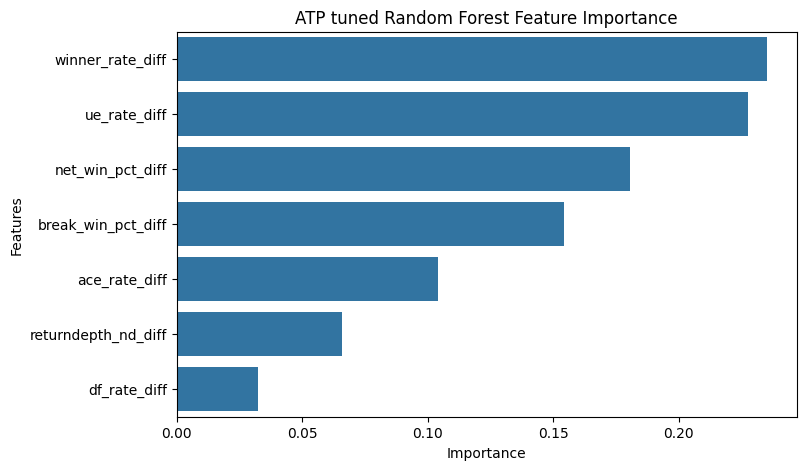

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(x=importance.values, y=importance.index)

plt.title('ATP tuned Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Features')

plt.show()

In [ ]:
b_rf_wta_importance = pd.Series(b_rf_wta.feature_importances_, index=ml_features)
importance = b_rf_wta_importance.sort_values(ascending=False)

print(importance)

winner_rate_diff       0.235504
ue_rate_diff           0.220859
break_win_pct_diff     0.195510
ace_rate_diff          0.127336
net_win_pct_diff       0.082237
returndepth_nd_diff    0.070366
df_rate_diff           0.068188
dtype: float64


In [ ]:
#xgboost
from xgboost import XGBClassifier

xg_atp = XGBClassifier(random_state=42)
xg_wta = XGBClassifier(random_state=42)

cv_results_xg_atp = cross_validate(
    xg_atp,
    X_train_atp,
    y_train_atp,
    cv=cv,
    scoring=scoring
)

xg_cv_f1_atp = cv_results_xg_atp['test_f1'].mean()
xg_cv_accuracy_atp = cv_results_xg_atp['test_accuracy'].mean()

cv_results_xg_wta = cross_validate(
    xg_wta,
    X_train_wta,
    y_train_wta,
    cv=cv,
    scoring=scoring
)

xg_cv_f1_wta = cv_results_xg_wta['test_f1'].mean()
xg_cv_accuracy_wta = cv_results_xg_wta['test_accuracy'].mean()

In [ ]:
xg_atp.fit(X_train_atp, y_train_atp)

y_pred_atp = xg_atp.predict(X_test_atp)
print("ATP XGB Accuracy:", accuracy_score(y_test_atp, y_pred_atp))
print("ATP XGB F1:", f1_score(y_test_atp, y_pred_atp))


ATP XGB Accuracy: 0.847682119205298
ATP XGB F1: 0.8345323741007195


In [ ]:
xg_wta.fit(X_train_wta, y_train_wta)
y_pred_wta = xg_wta.predict(X_test_wta)

print("WTA XGB Accuracy:", accuracy_score(y_test_wta, y_pred_wta))
print("WTA XGB F1:", f1_score(y_test_wta, y_pred_wta))

WTA XGB Accuracy: 0.847682119205298
WTA XGB F1: 0.8345323741007195


In [ ]:

atp_results.append({
    'model': 'XGBoost',
    'cv_accuracy':xg_cv_accuracy_atp,
    'cv_f1': xg_cv_f1_atp,
    'test_accuracy': accuracy_score(y_test_atp, y_pred_atp),
    'test_f1': f1_score(y_test_atp, y_pred_atp),
})

wta_results.append({
    'model': 'XGBoost',
    'cv_accuracy': xg_cv_accuracy_wta,
    'cv_f1': xg_cv_f1_wta,
    'test_accuracy': accuracy_score(y_test_wta, y_pred_wta),
    'test_f1': f1_score(y_test_wta, y_pred_wta),
})

In [ ]:
atp_results

[{'model': 'Logistic Regression',
  'cv_accuracy': np.float64(0.9002617079889808),
  'cv_f1': np.float64(0.8901154687678747),
  'test_accuracy': 0.8543046357615894,
  'test_f1': 0.8405797101449275},
 {'model': 'Random Forest',
  'cv_accuracy': np.float64(0.8686088154269971),
  'cv_f1': np.float64(0.8496285188847568),
  'test_accuracy': 0.8609271523178808,
  'test_f1': 0.8467153284671532},
 {'model': 'XGBoost',
  'cv_accuracy': np.float64(0.8586501377410469),
  'cv_f1': np.float64(0.839743700205337),
  'test_accuracy': 0.847682119205298,
  'test_f1': 0.8345323741007195},
 {'model': 'tuned Random Forest',
  'cv_accuracy': None,
  'cv_f1': np.float64(0.8640383571510928),
  'test_accuracy': 0.8675496688741722,
  'test_f1': 0.8571428571428571}]

In [ ]:
wta_results

[{'model': 'Logistic Regression',
  'cv_accuracy': np.float64(0.8875770308123249),
  'cv_f1': np.float64(0.887242777126151),
  'test_accuracy': 0.9133333333333333,
  'test_f1': 0.9090909090909091},
 {'model': 'Random Forest',
  'cv_accuracy': np.float64(0.8842296918767507),
  'cv_f1': np.float64(0.884358165718972),
  'test_accuracy': 0.8933333333333333,
  'test_f1': 0.8873239436619719},
 {'model': 'XGBoost',
  'cv_accuracy': np.float64(0.882577030812325),
  'cv_f1': np.float64(0.883007828304286),
  'test_accuracy': 0.9,
  'test_f1': 0.8993288590604027},
 {'model': 'tuned Random Forest',
  'cv_accuracy': None,
  'cv_f1': np.float64(0.8867432923582657),
  'test_accuracy': 0.8866666666666667,
  'test_f1': 0.8811188811188811}]

In [ ]:
xgb_model = XGBClassifier(random_state=42)

param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [2, 3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0]

}

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

xgb_search_atp = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid_xgb,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

In [ ]:
xgb_search_atp.fit(X_train_atp, y_train_atp)

print("Best ATP XGB params:", xgb_search_atp.best_params_)
print("Best ATP XGB CV F1:", xgb_search_atp.best_score_)

Best ATP XGB params: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}
Best ATP XGB CV F1: 0.861328974102063


In [ ]:
best_xgb_atp = xgb_search_atp.best_estimator_
b_y_pred_xgb_atp = best_xgb_atp.predict(X_test_atp)

print("ATP XGB tuned Test Accuracy:", accuracy_score(y_test_atp, b_y_pred_xgb_atp))
print("ATP XGB tuned Test F1:", f1_score(y_test_atp, b_y_pred_xgb_atp))
print(confusion_matrix(y_test_atp, b_y_pred_xgb_atp))

ATP XGB tuned Test Accuracy: 0.8543046357615894
ATP XGB tuned Test F1: 0.8405797101449275
[[71  9]
 [13 58]]


In [ ]:
xgb_search_wta = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid_xgb,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)


In [ ]:
xgb_search_wta.fit(X_train_wta, y_train_wta)

print("Best WTA XGB params:", xgb_search_wta.best_params_)
print("Best WTA XGB CV F1:", xgb_search_wta.best_score_)

Best WTA XGB params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 2, 'learning_rate': 0.05}
Best WTA XGB CV F1: 0.8888790959124118


In [ ]:
best_xgb_wta = xgb_search_wta.best_estimator_
b_y_pred_xgb_wta = best_xgb_wta.predict(X_test_wta)

print("WTA XGB tuned Test Accuracy:", accuracy_score(y_test_wta, b_y_pred_xgb_wta))
print("WTA XGB tuned Test F1:", f1_score(y_test_wta, b_y_pred_xgb_wta))
print(confusion_matrix(y_test_wta, b_y_pred_xgb_wta))

WTA XGB tuned Test Accuracy: 0.92
WTA XGB tuned Test F1: 0.9166666666666666
[[72  7]
 [ 5 66]]


In [ ]:
b_xgb_wta_importance = pd.Series(best_xgb_wta.feature_importances_, index=ml_features)
importance = b_xgb_wta_importance.sort_values(ascending=False)

print(importance)

break_win_pct_diff     0.257983
winner_rate_diff       0.182190
ue_rate_diff           0.171368
ace_rate_diff          0.167511
net_win_pct_diff       0.086817
returndepth_nd_diff    0.079832
df_rate_diff           0.054299
dtype: float32


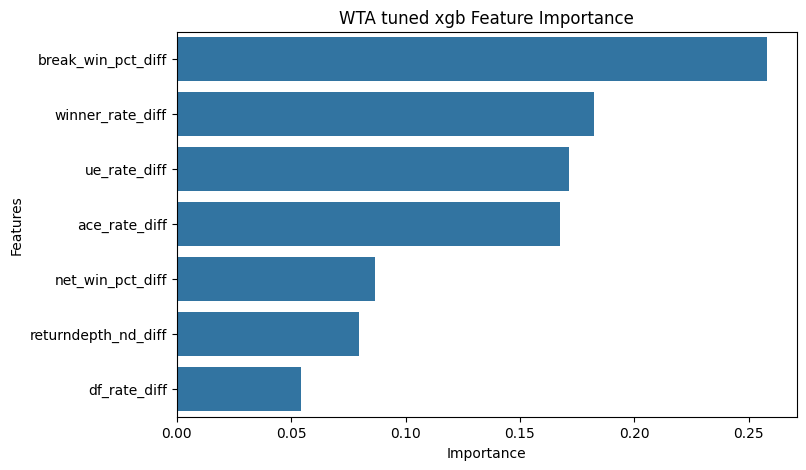

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(x=importance.values, y=importance.index)

plt.title('WTA tuned xgb Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Features')

plt.show()



In [ ]:
atp_results.append({
    'model': 'tuned XGBoost',
    'cv_accuracy': None,
    'cv_f1': xgb_search_atp.best_score_,
    'test_accuracy': accuracy_score(y_test_atp, b_y_pred_xgb_atp),
    'test_f1': f1_score(y_test_atp, b_y_pred_xgb_atp),
})

wta_results.append({
    'model': 'tuned XGBoost',
    'cv_accuracy': None,
    'cv_f1': xgb_search_wta.best_score_,
    'test_accuracy': accuracy_score(y_test_wta, b_y_pred_xgb_wta),
    'test_f1': f1_score(y_test_wta, b_y_pred_xgb_wta),
})

In [ ]:
atp_results

[{'model': 'Logistic Regression',
  'cv_accuracy': np.float64(0.9002617079889808),
  'cv_f1': np.float64(0.8901154687678747),
  'test_accuracy': 0.8543046357615894,
  'test_f1': 0.8405797101449275},
 {'model': 'Random Forest',
  'cv_accuracy': np.float64(0.8686088154269971),
  'cv_f1': np.float64(0.8496285188847568),
  'test_accuracy': 0.8609271523178808,
  'test_f1': 0.8467153284671532},
 {'model': 'XGBoost',
  'cv_accuracy': np.float64(0.8586501377410469),
  'cv_f1': np.float64(0.839743700205337),
  'test_accuracy': 0.847682119205298,
  'test_f1': 0.8345323741007195},
 {'model': 'tuned Random Forest',
  'cv_accuracy': None,
  'cv_f1': np.float64(0.8640383571510928),
  'test_accuracy': 0.8675496688741722,
  'test_f1': 0.8571428571428571},
 {'model': 'tuned XGBoost',
  'cv_accuracy': None,
  'cv_f1': np.float64(0.861328974102063),
  'test_accuracy': 0.8543046357615894,
  'test_f1': 0.8405797101449275}]

In [ ]:
wta_results

[{'model': 'Logistic Regression',
  'cv_accuracy': np.float64(0.8875770308123249),
  'cv_f1': np.float64(0.887242777126151),
  'test_accuracy': 0.9133333333333333,
  'test_f1': 0.9090909090909091},
 {'model': 'Random Forest',
  'cv_accuracy': np.float64(0.8842296918767507),
  'cv_f1': np.float64(0.884358165718972),
  'test_accuracy': 0.8933333333333333,
  'test_f1': 0.8873239436619719},
 {'model': 'XGBoost',
  'cv_accuracy': np.float64(0.882577030812325),
  'cv_f1': np.float64(0.883007828304286),
  'test_accuracy': 0.9,
  'test_f1': 0.8993288590604027},
 {'model': 'tuned Random Forest',
  'cv_accuracy': None,
  'cv_f1': np.float64(0.8867432923582657),
  'test_accuracy': 0.8866666666666667,
  'test_f1': 0.8811188811188811},
 {'model': 'tuned XGBoost',
  'cv_accuracy': None,
  'cv_f1': np.float64(0.8888790959124118),
  'test_accuracy': 0.92,
  'test_f1': 0.9166666666666666}]

In [ ]:
atp_results = pd.DataFrame(atp_results)
atp_results = atp_results.round(3)
wta_results = pd.DataFrame(wta_results)
wta_results = wta_results.round(3)

In [ ]:
atp_results

,model,cv_accuracy,cv_f1,test_accuracy,test_f1
0,Logistic Regression,0.900,0.890,0.854,0.841
1,Random Forest,0.869,0.850,0.861,0.847
2,XGBoost,0.859,0.840,0.848,0.835
3,tuned Random Forest,NaN,0.864,0.868,0.857
4,tuned XGBoost,NaN,0.861,0.854,0.841


In [ ]:
wta_results

,model,cv_accuracy,cv_f1,test_accuracy,test_f1
0,Logistic Regression,0.888,0.887,0.913,0.909
1,Random Forest,0.884,0.884,0.893,0.887
2,XGBoost,0.883,0.883,0.900,0.899
3,tuned Random Forest,NaN,0.887,0.887,0.881
4,tuned XGBoost,NaN,0.889,0.920,0.917
